# Análise de Despesas das Capitais Brasileiras (2020–2025)

**Fonte:** FINBRA/Siconfi — Despesas por Função (Anexo I-E)  
**Período:** 2020–2024 (2025 com apenas 11 capitais declaradas — excluído de comparações)  
**Indicador central:** Taxa de Execução = (Despesas Pagas ÷ Despesas Empenhadas) × 100  

Escolhi DuckDB como motor de consulta por permitir rodar SQL analítico diretamente sobre o
Parquet sem carregar tudo na memória — ideal para dados que tendem a crescer a cada ano.

In [1]:
import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

Path('saidas').mkdir(exist_ok=True)
sns.set_theme(style='whitegrid')
con = duckdb.connect('finbra.duckdb')

## 1. Completude dos dados por ano

Antes de qualquer análise, é preciso saber quantas capitais declararam dados em cada ano.
Comparar 2024 (26 capitais) com 2025 (11 capitais) em valores absolutos levaria a conclusões erradas.

 ano  capitais  pct_completo
2020        26         100.0
2021        26         100.0
2022        26         100.0
2023        26         100.0
2024        26         100.0
2025        11          42.0


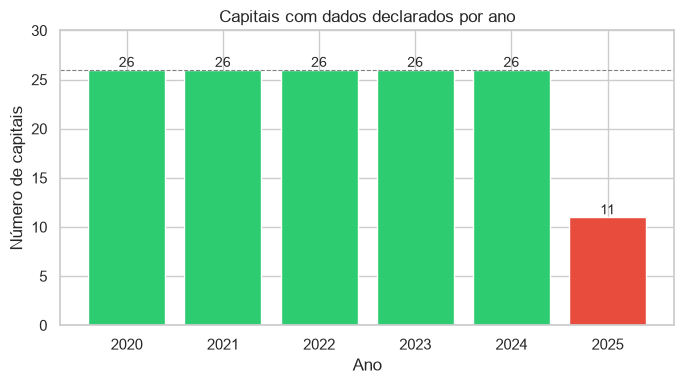

In [2]:
completude = con.execute("""
    SELECT
        ano,
        COUNT(DISTINCT \"Cod.IBGE\") AS capitais,
        ROUND(COUNT(DISTINCT \"Cod.IBGE\") * 100.0 / 26, 0) AS pct_completo
    FROM finbra
    WHERE tipo_conta = 'funcao'
    GROUP BY ano
    ORDER BY ano
""").df()

print(completude.to_string(index=False))

fig, ax = plt.subplots(figsize=(7, 4))
cores = ['#e74c3c' if c < 26 else '#2ecc71' for c in completude['capitais']]
ax.bar(completude['ano'].astype(str), completude['capitais'], color=cores)
ax.axhline(26, color='gray', linestyle='--', linewidth=0.8)
ax.set_ylim(0, 30)
ax.set_xlabel('Ano')
ax.set_ylabel('Número de capitais')
ax.set_title('Capitais com dados declarados por ano')
for i, (ano, cap) in enumerate(zip(completude['ano'], completude['capitais'])):
    ax.text(i, cap + 0.3, str(cap), ha='center', fontsize=10)
plt.tight_layout()
plt.savefig('saidas/completude.png', dpi=150)
plt.show()

## 2. Taxa de Execução por Capital (2020–2024)

Quanto do que cada capital **empenhou** efetivamente **saiu do caixa** no período?
Uma taxa baixa indica acúmulo de restos a pagar — compromissos que ficam para o ano seguinte.

Maceió (AL): 94.3% — 8º lugar entre 26 capitais


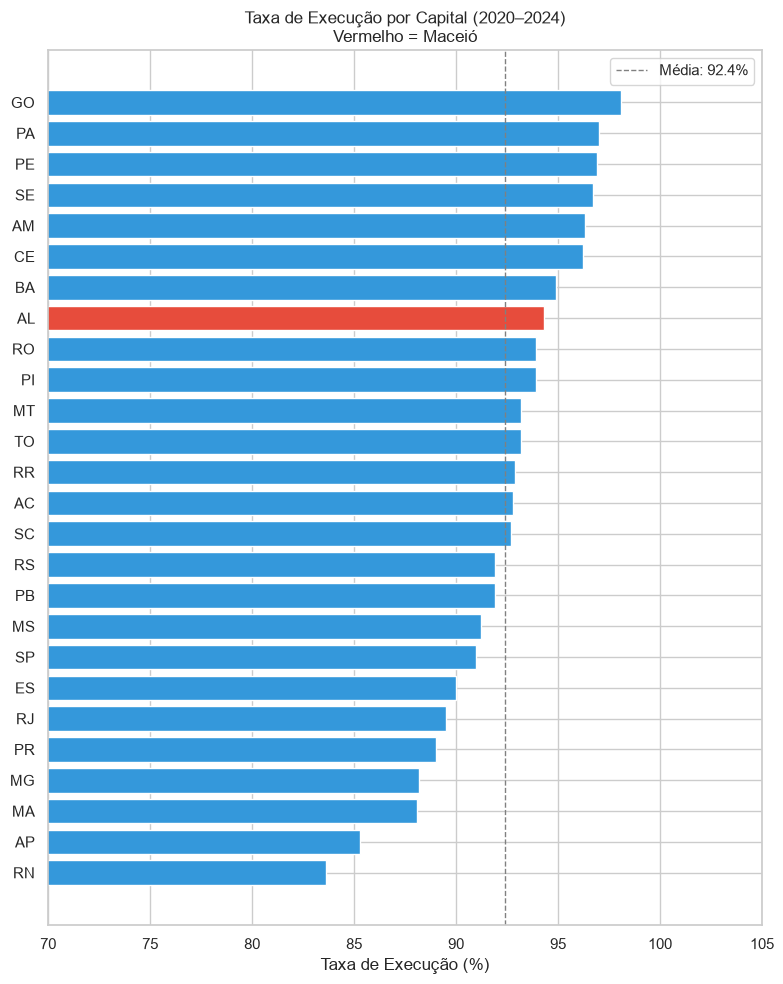

In [3]:
taxa_geral = con.execute("""
    SELECT
        UF,
        ROUND(
            100.0 * SUM(CASE WHEN Coluna = 'Despesas Pagas' THEN Valor ELSE 0 END) /
            NULLIF(SUM(CASE WHEN Coluna = 'Despesas Empenhadas' THEN Valor ELSE 0 END), 0),
        1) AS taxa_execucao
    FROM finbra
    WHERE tipo_conta = 'funcao'
      AND ano BETWEEN 2020 AND 2024
      AND Coluna IN ('Despesas Empenhadas', 'Despesas Pagas')
    GROUP BY UF
    ORDER BY taxa_execucao DESC
""").df()

taxa_geral['rank'] = range(1, len(taxa_geral) + 1)
maceio_taxa = taxa_geral.loc[taxa_geral['UF'] == 'AL', 'taxa_execucao'].values[0]
maceio_rank = taxa_geral.loc[taxa_geral['UF'] == 'AL', 'rank'].values[0]
print(f'Maceió (AL): {maceio_taxa}% — {maceio_rank}º lugar entre 26 capitais')

fig, ax = plt.subplots(figsize=(8, 10))
cores = ['#e74c3c' if uf == 'AL' else '#3498db' for uf in taxa_geral['UF']]
ax.barh(taxa_geral['UF'][::-1], taxa_geral['taxa_execucao'][::-1], color=cores[::-1])
ax.axvline(taxa_geral['taxa_execucao'].mean(), color='gray', linestyle='--', linewidth=1,
           label=f'Média: {taxa_geral["taxa_execucao"].mean():.1f}%')
ax.set_xlabel('Taxa de Execução (%)')
ax.set_title('Taxa de Execução por Capital (2020–2024)\nVermelho = Maceió')
ax.legend()
ax.set_xlim(70, 105)
plt.tight_layout()
plt.savefig('saidas/taxa_execucao_geral.png', dpi=150)
plt.show()

## 3. Taxa de Execução por Função (Top 8)

O comportamento muda bastante dependendo da área de atuação. Algumas funções têm execução
quase total; outras acumulam sistematicamente restos a pagar.

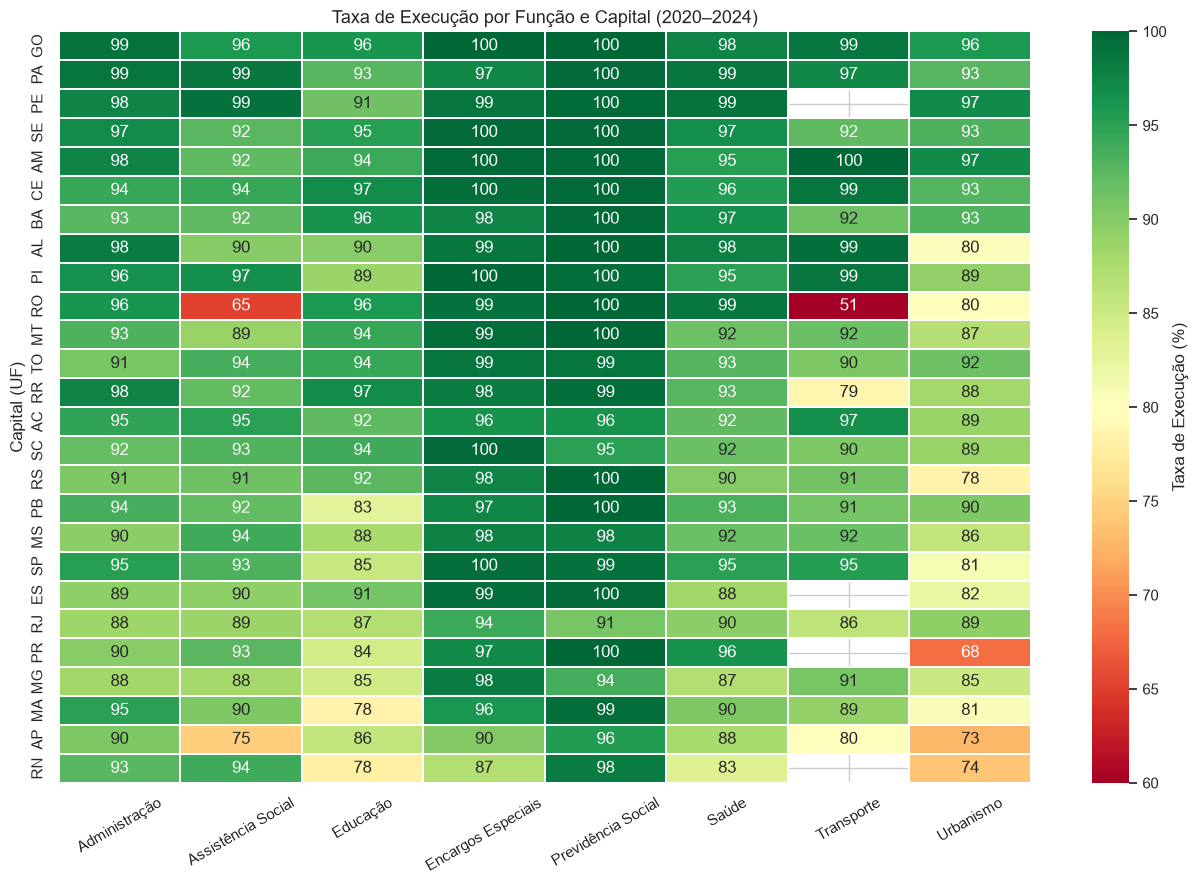

In [4]:
top_funcoes = con.execute("""
    SELECT Conta
    FROM finbra
    WHERE tipo_conta = 'funcao' AND ano BETWEEN 2020 AND 2024
      AND Coluna = 'Despesas Pagas'
    GROUP BY Conta
    ORDER BY SUM(Valor) DESC
    LIMIT 8
""").df()['Conta'].tolist()

placeholders = ', '.join([f"'{c}'" for c in top_funcoes])

heatmap_df = con.execute(f"""
    SELECT
        UF,
        SPLIT_PART(Conta, ' - ', 2) AS funcao,
        ROUND(
            100.0 * SUM(CASE WHEN Coluna = 'Despesas Pagas' THEN Valor ELSE 0 END) /
            NULLIF(SUM(CASE WHEN Coluna = 'Despesas Empenhadas' THEN Valor ELSE 0 END), 0),
        1) AS taxa
    FROM finbra
    WHERE tipo_conta = 'funcao'
      AND ano BETWEEN 2020 AND 2024
      AND Coluna IN ('Despesas Empenhadas', 'Despesas Pagas')
      AND Conta IN ({placeholders})
    GROUP BY UF, Conta
""").df()

pivot = heatmap_df.pivot(index='UF', columns='funcao', values='taxa')
ordem_uf = taxa_geral.set_index('UF')['taxa_execucao'].reindex(pivot.index).sort_values(ascending=False).index
pivot = pivot.loc[ordem_uf]

fig, ax = plt.subplots(figsize=(13, 9))
sns.heatmap(pivot, annot=True, fmt='.0f', cmap='RdYlGn', vmin=60, vmax=100,
            linewidths=0.3, ax=ax, cbar_kws={'label': 'Taxa de Execução (%)'})
ax.set_title('Taxa de Execução por Função e Capital (2020–2024)', fontsize=13)
ax.set_xlabel('')
ax.set_ylabel('Capital (UF)')
ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.savefig('saidas/heatmap_taxa_funcao.png', dpi=150)
plt.show()

## 4. Saúde e Educação — Gasto Per Capita (2024)

Comparar valores absolutos é injusto: São Paulo tem população 20× maior que Boa Vista.
O gasto **por habitante** nivela o campo e revela quem de fato investe mais.

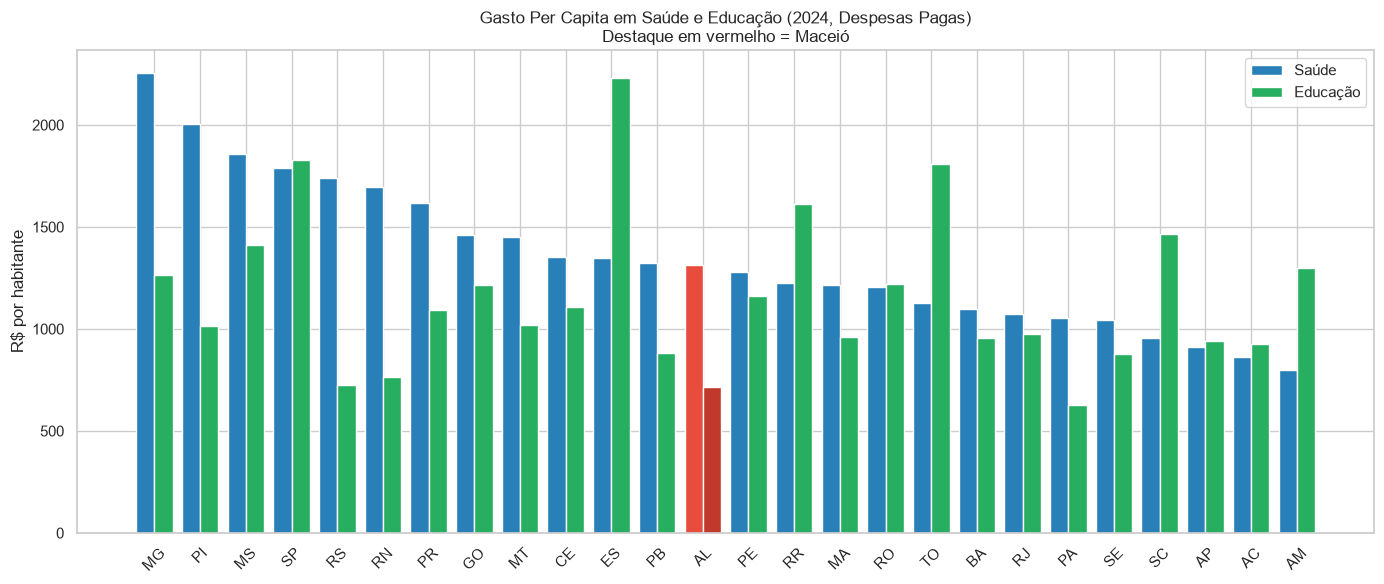

Maceió — Saúde: R$ 1,315/hab (13º); Educação: R$ 716/hab (25º)


In [5]:
per_capita = con.execute("""
    SELECT
        UF,
        ROUND(SUM(CASE WHEN Conta LIKE '10 - %' THEN Valor ELSE 0 END) / MAX(\"População\"), 0) AS saude,
        ROUND(SUM(CASE WHEN Conta LIKE '12 - %' THEN Valor ELSE 0 END) / MAX(\"População\"), 0) AS educacao
    FROM finbra
    WHERE tipo_conta = 'funcao'
      AND ano = 2024
      AND Coluna = 'Despesas Pagas'
    GROUP BY UF
    ORDER BY saude DESC
""").df()

x = range(len(per_capita))
w = 0.4
cores_s = ['#e74c3c' if uf == 'AL' else '#2980b9' for uf in per_capita['UF']]
cores_e = ['#c0392b' if uf == 'AL' else '#27ae60' for uf in per_capita['UF']]

fig, ax = plt.subplots(figsize=(14, 6))
ax.bar([i - w/2 for i in x], per_capita['saude'], width=w, color=cores_s, label='Saúde')
ax.bar([i + w/2 for i in x], per_capita['educacao'], width=w, color=cores_e, label='Educação')
ax.set_xticks(list(x))
ax.set_xticklabels(per_capita['UF'], rotation=45)
ax.set_ylabel('R$ por habitante')
ax.set_title('Gasto Per Capita em Saúde e Educação (2024, Despesas Pagas)\nDestaque em vermelho = Maceió')
ax.legend()
plt.tight_layout()
plt.savefig('saidas/per_capita_saude_educacao.png', dpi=150)
plt.show()

maceio_s = per_capita.loc[per_capita['UF'] == 'AL', 'saude'].values[0]
maceio_e = per_capita.loc[per_capita['UF'] == 'AL', 'educacao'].values[0]
rank_s = per_capita['UF'].tolist().index('AL') + 1
rank_e = per_capita.sort_values('educacao', ascending=False)['UF'].tolist().index('AL') + 1
print(f'Maceió — Saúde: R$ {maceio_s:,.0f}/hab ({rank_s}º); Educação: R$ {maceio_e:,.0f}/hab ({rank_e}º)')

## 5. Evolução Temporal — Maceió vs Média das Capitais (2020–2024)

Acompanhar a trajetória de Maceió ao longo dos anos, comparada à média geral,
revela se o município está convergindo ou se distanciando das demais capitais.

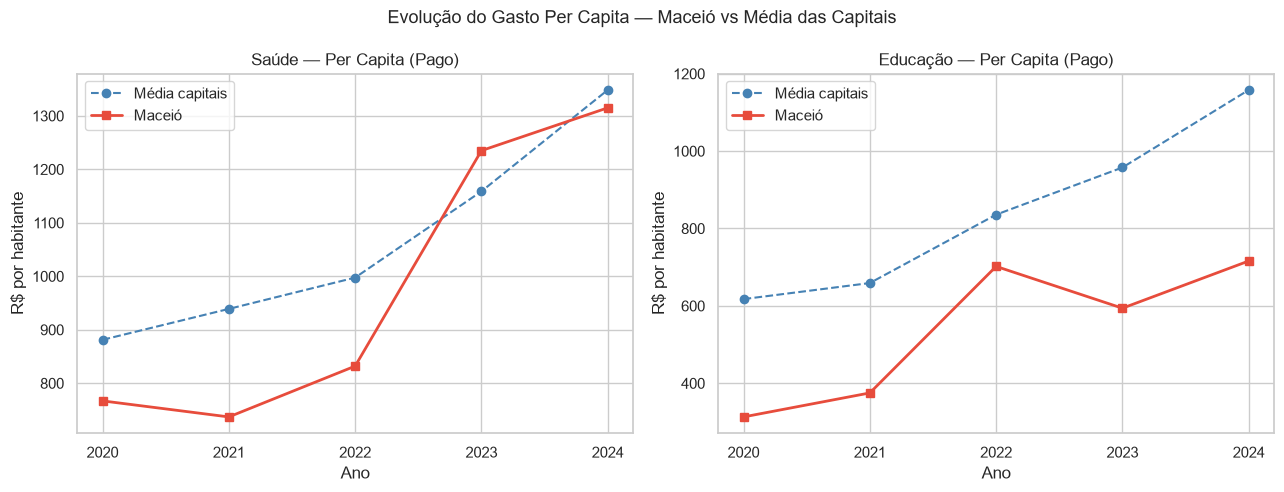

In [6]:
evolucao = con.execute("""
    SELECT
        ano, UF,
        ROUND(SUM(CASE WHEN Conta LIKE '10 - %' THEN Valor ELSE 0 END) / MAX(\"População\"), 0) AS saude_pc,
        ROUND(SUM(CASE WHEN Conta LIKE '12 - %' THEN Valor ELSE 0 END) / MAX(\"População\"), 0) AS educ_pc
    FROM finbra
    WHERE tipo_conta = 'funcao'
      AND ano <= 2024
      AND Coluna = 'Despesas Pagas'
    GROUP BY ano, UF
    ORDER BY ano, UF
""").df()

media = evolucao.groupby('ano')[['saude_pc', 'educ_pc']].mean().reset_index()
maceio = evolucao[evolucao['UF'] == 'AL'].copy()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(media['ano'], media['saude_pc'], 'o--', color='steelblue', label='Média capitais')
axes[0].plot(maceio['ano'], maceio['saude_pc'], 's-', color='#e74c3c', linewidth=2, label='Maceió')
axes[0].set_title('Saúde — Per Capita (Pago)')
axes[0].set_ylabel('R$ por habitante')
axes[0].legend()

axes[1].plot(media['ano'], media['educ_pc'], 'o--', color='steelblue', label='Média capitais')
axes[1].plot(maceio['ano'], maceio['educ_pc'], 's-', color='#e74c3c', linewidth=2, label='Maceió')
axes[1].set_title('Educação — Per Capita (Pago)')
axes[1].set_ylabel('R$ por habitante')
axes[1].legend()

for ax in axes:
    ax.set_xlabel('Ano')
    ax.set_xticks([2020, 2021, 2022, 2023, 2024])

plt.suptitle('Evolução do Gasto Per Capita — Maceió vs Média das Capitais', fontsize=13)
plt.tight_layout()
plt.savefig('saidas/evolucao_maceio.png', dpi=150)
plt.show()

## 6. Síntese — Posicionamento de Maceió

Resumo quantitativo de onde Maceió se posiciona em cada dimensão analisada.

In [7]:
taxa_por_funcao = con.execute("""
    SELECT
        UF,
        SPLIT_PART(Conta, ' - ', 2) AS funcao,
        ROUND(
            100.0 * SUM(CASE WHEN Coluna = 'Despesas Pagas' THEN Valor ELSE 0 END) /
            NULLIF(SUM(CASE WHEN Coluna = 'Despesas Empenhadas' THEN Valor ELSE 0 END), 0),
        1) AS taxa
    FROM finbra
    WHERE tipo_conta = 'funcao'
      AND ano BETWEEN 2020 AND 2024
      AND Coluna IN ('Despesas Empenhadas', 'Despesas Pagas')
    GROUP BY UF, Conta
    ORDER BY funcao, taxa DESC
""").df()

ranking = (
    taxa_por_funcao
    .assign(rank=taxa_por_funcao.groupby('funcao')['taxa'].rank(ascending=False).astype(int))
    .query("UF == 'AL'")
    .sort_values('taxa', ascending=False)
    [['funcao', 'taxa', 'rank']]
    .rename(columns={'funcao': 'Função', 'taxa': 'Taxa Exec. (%)', 'rank': 'Ranking (de 26)'})
)

print('Maceió — Taxa de Execução por Função (2020–2024):')
print(ranking.to_string(index=False))

print(f'\nTaxa geral: {maceio_taxa}% — {maceio_rank}º entre 26 capitais')
print(f'Saúde per capita 2024: R$ {maceio_s:,.0f}/hab — {rank_s}º lugar')
print(f'Educação per capita 2024: R$ {maceio_e:,.0f}/hab — {rank_e}º lugar')

Maceió — Taxa de Execução por Função (2020–2024):
               Função  Taxa Exec. (%)  Ranking (de 26)
   Previdência Social            99.9                4
           Transporte            99.4                2
          Legislativa            99.3                5
     Gestão Ambiental            98.9                2
   Encargos Especiais            98.7               12
        Administração            98.3                3
             Trabalho            98.1                6
                Saúde            97.9                4
  Comércio e Serviços            95.6                5
           Saneamento            92.6                9
    Segurança Pública            90.9               19
   Assistência Social            89.9               20
             Educação            89.7               16
 Ciência e Tecnologia            89.6                9
              Cultura            87.8                9
     Desporto e Lazer            86.0               19
            Urb